# Double split-ring resonator (SRR) analytical design

Analytical starting point for a double SRR designed to hit a target resonance frequency $f_0$ and unloaded quality factor $Q$, following the series-RLC model (Bahl-type loop inductance + Hilberg coupled-strip capacitance for the inter-ring gap).

**Assumptions made explicit (not stated in the original formulas):**
- Elliptic modulus for the inter-ring gap capacitance: $k = d/(d+2c)$ (standard coupled-coplanar-strip convention; checked against limits $C\to\infty$ as $d\to0$, $C\to0$ as $d\to\infty$).
- Conductor-loss formula assumes metal thickness $t \gg$ skin depth $\delta$ at $f_0$ — checked explicitly below rather than assumed.
- Split gap $g$ does not enter the analytical $L$/$C$ model (per the design notes, essentially all the capacitance comes from the inter-ring gap $d$, not the split gaps) — it is carried through only as a fixed fabrication parameter for the final geometry table.
- Radiation Q is not modeled analytically; the electrical-size ratio (circumference / $\lambda_\mathrm{eff}$) is reported instead as a proxy for "radiation loss should be negligible."

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import ellipk, ellipe
from scipy.optimize import brentq

mu0 = 4 * np.pi * 1e-7  # vacuum permeability [H/m]
eps0 = 8.8541878128e-12  # vacuum permittivity [F/m]
c0 = 299792458.0  # speed of light [m/s]

## Design inputs

Substrate: FR4. Target: $f_0 = 2.87$ GHz. Metal: 1 oz copper (0.035 mm).

In [2]:
# Substrate (FR4)
er = 4.4  # relative permittivity
h = 1.6e-3  # substrate thickness [m], standard FR4 panel thickness
tan_delta = 0.02  # loss tangent

# Metal
sigma = 5.8e7  # copper conductivity [S/m]
t = 0.035e-3  # copper thickness [m] (1 oz copper)

# Targets
f0_target = 2.87e9  # target resonance frequency [Hz]
Q_target = 50  # target unloaded Q (modest target given lossy FR4)

# Starting topology (fabrication-constrained / initial guesses)
c_width = 1.0e-3  # ring trace width [m]
g_gap = 0.3e-3  # split gap [m] (fixed fab constraint, not used in LC model)
d_gap = 0.3e-3  # inter-ring gap [m] (initial guess, dominant capacitance lever)
r_guess = 5.0e-3  # mean ring radius [m] (initial guess, dominant inductance lever)

## Core physics functions

$\varepsilon_\mathrm{eff}$ (microstrip effective permittivity), $L$ (Wheeler loop inductance), and $C_\mathrm{eq}$ (Hilberg coupled-strip capacitance, bent into a ring).

In [3]:
def eps_eff(er, h, w):
    """Microstrip effective permittivity (Hammerstad-Jensen)."""
    return (er + 1) / 2 + (er - 1) / 2 * (1 + 12 * h / w) ** -0.5


def inductance(r, c):
    """Wheeler-type single-turn loop inductance, mean radius r, trace width c."""
    return mu0 * r * (np.log(8 * r / c) - 2)


def elliptic_ratio(d, c):
    """K(k')/K(k) for the inter-ring coupled-strip gap, k = d/(d+2c)."""
    k = d / (d + 2 * c)
    kp = np.sqrt(1 - k**2)
    K = ellipk(k**2)  # scipy's ellipk takes the parameter m = k^2
    Kp = ellipk(kp**2)
    return Kp / K


def capacitance(er, h, c, d, r):
    """Total series capacitance of the two half-rings (inter-ring gap dominates)."""
    eeff = eps_eff(er, h, c)
    ratio = elliptic_ratio(d, c)
    C_pul = eps0 * (1 + eeff) * ratio
    circumference = 2 * np.pi * r
    return C_pul * circumference / 2


def resonance_freq(L, C):
    return 1 / (2 * np.pi * np.sqrt(L * C))

## Loss / Q functions

Conductor loss via skin-effect surface resistance, dielectric loss via $\tan\delta$, combined into $Q_\mathrm{total}$.

In [4]:
def skin_depth(f, sigma):
    return np.sqrt(1 / (np.pi * f * mu0 * sigma))


def surface_resistance(f, sigma):
    return np.sqrt(np.pi * f * mu0 / sigma)


def resistance(r, c, f, sigma):
    circumference = 2 * np.pi * r
    Rs = surface_resistance(f, sigma)
    return circumference * Rs / c


def Q_conductor(L, C, R):
    omega0 = 2 * np.pi * resonance_freq(L, C)
    return omega0 * L / R


def Q_dielectric(tan_delta):
    return 1 / tan_delta


def Q_combined(Q_cond, Q_diel):
    return 1 / (1 / Q_cond + 1 / Q_diel)


def design_point(r, c, d, er, h, tan_delta, sigma):
    """Full L/C/f0/Q evaluation for one geometry, returned as a dict."""
    L = inductance(r, c)
    C = capacitance(er, h, c, d, r)
    f0 = resonance_freq(L, C)
    R = resistance(r, c, f0, sigma)
    Qc = Q_conductor(L, C, R)
    Qd = Q_dielectric(tan_delta)
    Qt = Q_combined(Qc, Qd)
    return {"L": L, "C": C, "f0": f0, "R": R, "Q_cond": Qc, "Q_diel": Qd, "Q_total": Qt}

## Physical ring radii

`r` is the mean radius of the whole double-ring structure — the average of the two rings' own centerline radii, which sit `c + d` apart (trace width plus inter-ring gap). From that, the innermost edge of the inner ring and outermost edge of the outer ring (the two radii you'd actually draw for fabrication) follow directly.

In [ ]:
def ring_radii(r, c, d):
    """Physical inner/outer edge radii of the double-ring structure.

    r : mean radius of the whole structure (the value used in inductance()/capacitance()).
    c : trace width, d : inter-ring gap.
    """
    r_inner_mean = r - (c + d) / 2  # centerline radius of the inner ring
    r_outer_mean = r + (c + d) / 2  # centerline radius of the outer ring
    inner_radius = r_inner_mean - c / 2  # innermost edge of the inner ring
    outer_radius = r_outer_mean + c / 2  # outermost edge of the outer ring
    return inner_radius, outer_radius

## Solve for geometry hitting the target $f_0$

$f_0(r)$ is monotonically decreasing (both $L$ and $C$ grow with $r$), so a bracketed root find on $r$ converges reliably. If the resulting $Q$ falls short of target, widen the trace $c$ (lowers $R$, raises $Q_\mathrm{cond}$) and re-solve for $r$.

In [5]:
def solve_radius(c, d, f0_target, er, h):
    """Root-find the mean radius r that hits f0_target for fixed c, d.

    Wheeler's loop formula has a singularity at r = c*exp(2)/8, where L -> 0
    and f0 -> infinity, so bracketing just above that point (rather than an
    arbitrary fixed r_min) guarantees f(r_min) > f0_target regardless of c.
    """
    r_min = c * np.exp(2) / 8 * 1.001
    r_max = 500e-3
    def residual(r):
        L = inductance(r, c)
        C = capacitance(er, h, c, d, r)
        return resonance_freq(L, C) - f0_target
    return brentq(residual, r_min, r_max)


c_current = c_width
max_width_fraction = 0.5  # stop widening c if it would exceed half the radius
widen_step = 1.2
max_iters = 20

for i in range(max_iters):
    r_solved = solve_radius(c_current, d_gap, f0_target, er, h)
    point = design_point(r_solved, c_current, d_gap, er, h, tan_delta, sigma)
    if point["Q_total"] >= Q_target:
        break
    if c_current > max_width_fraction * r_solved:
        print(f"Stopped widening: c would exceed {max_width_fraction:.0%} of r at iteration {i}.")
        break
    c_current *= widen_step
else:
    print(f"Reached max_iters={max_iters} without hitting Q_target.")

print(f"Solved geometry: r = {r_solved*1e3:.3f} mm, c = {c_current*1e3:.3f} mm, d = {d_gap*1e3:.3f} mm")
print(f"f0 = {point['f0']/1e9:.4f} GHz (target {f0_target/1e9:.4f} GHz)")
print(f"Q_cond = {point['Q_cond']:.1f}, Q_diel = {point['Q_diel']:.1f}, Q_total = {point['Q_total']:.1f} (target {Q_target})")

Stopped widening: c would exceed 50% of r at iteration 3.
Solved geometry: r = 3.364 mm, c = 1.728 mm, d = 0.300 mm
f0 = 2.8700 GHz (target 2.8700 GHz)
Q_cond = 332.4, Q_diel = 50.0, Q_total = 43.5 (target 50)


## Sensitivity sweeps

$f_0$ vs $r$ and vs $d$ (the two levers from the design procedure), and $Q_\mathrm{total}$ vs $c$.

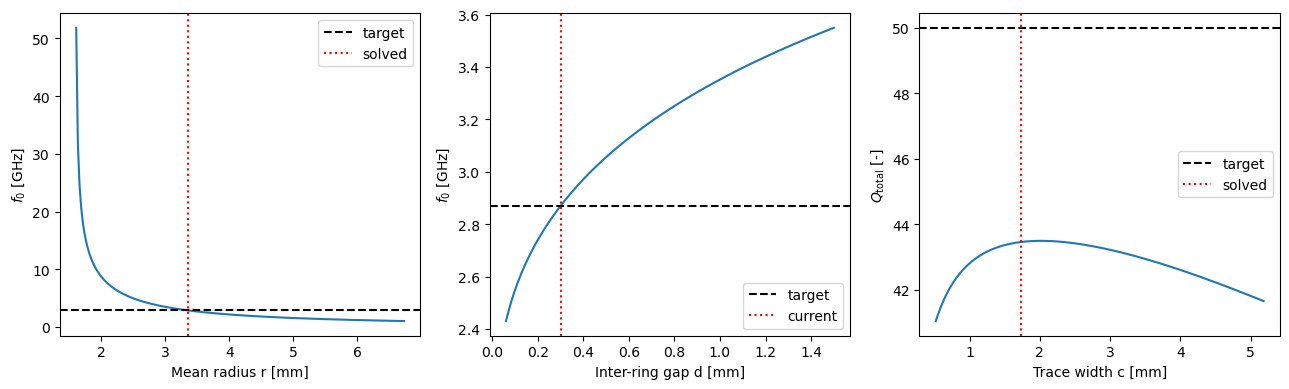

In [6]:
fig, axes = plt.subplot_mosaic([["r", "d", "c"]], figsize=(13, 4))

r_min_valid = c_current * np.exp(2) / 8 * 1.01  # stay above the L=0 singularity
r_sweep = np.linspace(max(0.3 * r_solved, r_min_valid), 2.0 * r_solved, 200)
f0_vs_r = [resonance_freq(inductance(r, c_current), capacitance(er, h, c_current, d_gap, r)) for r in r_sweep]
axes["r"].plot(r_sweep * 1e3, np.array(f0_vs_r) / 1e9)
axes["r"].axhline(f0_target / 1e9, color="k", linestyle="--", label="target")
axes["r"].axvline(r_solved * 1e3, color="r", linestyle=":", label="solved")
axes["r"].set_xlabel("Mean radius r [mm]")
axes["r"].set_ylabel("$f_0$ [GHz]")
axes["r"].legend()

d_sweep = np.linspace(0.2 * d_gap, 5.0 * d_gap, 200)
f0_vs_d = [resonance_freq(inductance(r_solved, c_current), capacitance(er, h, c_current, d, r_solved)) for d in d_sweep]
axes["d"].plot(d_sweep * 1e3, np.array(f0_vs_d) / 1e9)
axes["d"].axhline(f0_target / 1e9, color="k", linestyle="--", label="target")
axes["d"].axvline(d_gap * 1e3, color="r", linestyle=":", label="current")
axes["d"].set_xlabel("Inter-ring gap d [mm]")
axes["d"].set_ylabel("$f_0$ [GHz]")
axes["d"].legend()

c_sweep = np.linspace(0.3 * c_current, 3.0 * c_current, 200)
Q_vs_c = []
for c in c_sweep:
    r_c = solve_radius(c, d_gap, f0_target, er, h)
    Q_vs_c.append(design_point(r_c, c, d_gap, er, h, tan_delta, sigma)["Q_total"])
axes["c"].plot(c_sweep * 1e3, Q_vs_c)
axes["c"].axhline(Q_target, color="k", linestyle="--", label="target")
axes["c"].axvline(c_current * 1e3, color="r", linestyle=":", label="solved")
axes["c"].set_xlabel("Trace width c [mm]")
axes["c"].set_ylabel("$Q_\\mathrm{total}$ [-]")
axes["c"].legend()

fig.tight_layout()
plt.show()

## Validity checks

1. Electrical size: circumference / $\lambda_\mathrm{eff}$ should sit in the 0.1-0.25 range (electrically small, lumped-LC assumption valid, radiation loss negligible).
2. Skin depth vs metal thickness: $t$ should be several skin depths at $f_0$ for the surface-resistance formula to hold.

In [ ]:
lambda_eff = c0 / (point["f0"] * np.sqrt(eps_eff(er, h, c_current)))
circumference = 2 * np.pi * r_solved
size_ratio = circumference / lambda_eff
size_ok = 0.1 <= size_ratio <= 0.25

delta = skin_depth(point["f0"], sigma)
thickness_ratio = t / delta
thickness_ok = thickness_ratio >= 3

print(f"Electrical size (circumference / lambda_eff) = {size_ratio:.3f}  -> {'OK' if size_ok else 'OUT OF RANGE (0.1-0.25)'}")
print(f"Skin depth at f0 = {delta*1e6:.2f} um, copper thickness = {t*1e6:.1f} um, t/delta = {thickness_ratio:.2f} -> {'OK (t >> delta)' if thickness_ok else 'THIN: R underestimated'}")

## Estimating S11 from Q

Model the resonator as a series R-L-C sitting directly in a $Z_0$ transmission line (no separate external coupling network modeled): $Z(f) = R\,(1 + jQ(f/f_0 - f_0/f))$, with $R$ backed out from the already-computed $f_0$, $L$, and $Q_\mathrm{total}$ via $R = \omega_0 L / Q_\mathrm{total}$. Then $S_{11}(f) = (Z-Z_0)/(Z+Z_0)$.

This gives a rough reflection dip depth and width for the solved design point — the same quantities you'd read off a VNA per your original step 8 (resonance + 3-dB bandwidth). Caveat: for a high-Q, low-loss resonator, $R \ll Z_0$, so this direct-series model barely perturbs the line and the dip stays shallow — it's a lower bound on achievable dip depth, not a stand-in for a real coupling network (inductive/capacitive feed loop with a chosen coupling coefficient).

In [ ]:
def series_rlc_impedance(f, f0, Q, R):
    """Series R-L-C impedance near resonance, parameterized by Q instead of L, C directly."""
    return R * (1 + 1j * Q * (f / f0 - f0 / f))


def s11_from_Q(f, f0, Q, R, Z0=50.0):
    """One-port reflection coefficient vs frequency from f0, Q, and resonant series resistance R.

    Assumes the R-L-C sits directly in series with a Z0 line (no separate coupling
    network) -- a rough estimate of dip depth/width, not a substitute for modeling
    the actual feed coupling.
    """
    Z = series_rlc_impedance(f, f0, Q, R)
    return (Z - Z0) / (Z + Z0)

In [ ]:
R_eff = 2 * np.pi * point["f0"] * point["L"] / point["Q_total"]

f_span = np.linspace(point["f0"] * (1 - 5 / point["Q_total"]), point["f0"] * (1 + 5 / point["Q_total"]), 2000)
s11 = s11_from_Q(f_span, point["f0"], point["Q_total"], R_eff)
s11_db = 20 * np.log10(np.abs(s11))
dip_db = s11_db.min()

fig, ax = plt.subplots()
ax.plot((f_span - point["f0"]) / 1e6, s11_db)
ax.axhline(-3, color="k", linestyle="--", label="-3 dB")
ax.axvline(0, color="r", linestyle=":", label="f0")
ax.set_xlabel("f - f0 [MHz]")
ax.set_ylabel("$|S_{11}|$ [dB]")
ax.legend()
plt.show()

print(f"R_eff (back-calculated from Q_total) = {R_eff:.3f} ohm")
print(f"S11 dip at f0 = {dip_db:.2f} dB")

below_3db = s11_db <= -3
if below_3db.any():
    f_lo, f_hi = f_span[below_3db].min(), f_span[below_3db].max()
    Q_extracted = point["f0"] / (f_hi - f_lo)
    print(f"3-dB bandwidth = {(f_hi - f_lo)/1e6:.3f} MHz -> Q_extracted = {Q_extracted:.1f} (input Q_total = {point['Q_total']:.1f})")
else:
    print(
        "Dip never reaches -3 dB: R_eff is much smaller than Z0, so a resonator "
        "placed directly in series with the line barely perturbs it. A real SRR "
        "sensor needs a deliberate coupling network (inductive/capacitive feed loop, "
        "coupling coefficient g = Q_unloaded/Q_external) to pull the dip down -- "
        "this direct-series model is only a lower bound on achievable dip depth."
    )

## Optimal coupling trace width and gap (critical coupling)

Corrected geometry: the coupling is a **localized end gap** between a straight feed stub (width $w$) and the outer ring's tangent edge (gap $d_2$), matching the standard double-SRR feed layout -- not a second ring wrapped around the whole circumference (that was the earlier, wrong picture). This is a point-like microstrip discontinuity, not a distributed coupled-line problem, so the inter-ring elliptic-integral formula doesn't apply here; it needs the classic microstrip *gap discontinuity* formula instead.

Model (Garg & Bahl, 1978, as tabulated in Bahl's *Lumped Elements for RF and Microwave Circuits* -- the same reference this whole design already follows):
- Odd/even-mode gap capacitances per unit trace width, as a function of gap-to-substrate-height ratio $s/h$:
  $$C_\mathrm{odd}/w = \left(\frac{\varepsilon_r}{9.6}\right)^{0.8}\left(\frac{s}{h}\right)^{-0.9}\left[0.12 - 0.047\ln(s/h)\right]\ \mathrm{pF/cm}$$
  $$C_\mathrm{even}/w = \left(\frac{\varepsilon_r}{9.6}\right)^{0.9}\left(\frac{s}{h}\right)^{-0.8}\left[0.055 - 0.0125\ln(s/h)\right]\ \mathrm{pF/cm}$$
  valid for roughly $0.1 \le w/h \le 3$, $2.5 \le \varepsilon_r \le 15$.
- Series gap capacitance from the $\pi$-network equivalent circuit: $C_c = C_\mathrm{odd}/2$.
- Critical coupling condition is unchanged: $C_{c,\mathrm{crit}} = 1/(\omega_0\sqrt{R Z_0})$.
- Feed trace width $w$: still fixed to the 50 $\Omega$ microstrip width for the substrate.

**Honesty flag:** I'm recalling the odd/even polynomial coefficients above from memory, not from the primary reference in front of me -- double-check them against Bahl's book or the original Garg-Bahl (1978) paper before trusting absolute pF values. The formula *structure* (odd/even mode capacitance, $C_c=C_\mathrm{odd}/2$) is standard; the numeric coefficients are the part I'm less certain of.

A quick magnitude check below: this localized-gap capacitance tops out in the sub-pF range even at very small gaps -- much smaller than the several-pF the full-loop model produced, because it's now a point discontinuity rather than something integrated over 33 mm of circumference.

In [ ]:
def microstrip_z0(w, h, er):
    """Hammerstad closed-form microstrip characteristic impedance (wide-strip regime, w/h > 1)."""
    eeff = eps_eff(er, h, w)
    return 120 * np.pi / (np.sqrt(eeff) * (w / h + 1.393 + 0.667 * np.log(w / h + 1.444)))


def solve_microstrip_width(z0_target, h, er, w_bracket=(0.05e-3, 50e-3)):
    """Root-find the trace width giving the target characteristic impedance."""
    def residual(w):
        return microstrip_z0(w, h, er) - z0_target
    return brentq(residual, *w_bracket)


def gap_odd_even_capacitance(w, s, er, h):
    """Garg-Bahl (1978) microstrip gap-discontinuity odd/even-mode capacitances.

    Empirical fit, valid for roughly 0.1 <= w/h <= 3, 2.5 <= er <= 15.
    Coefficients recalled from memory -- cross-check against the primary
    reference (Bahl, "Lumped Elements for RF and Microwave Circuits") before
    trusting absolute pF values.
    """
    sh = s / h  # dimensionless, cm/cm factors cancel
    w_cm = w * 100
    C_odd_per_w = (er / 9.6) ** 0.8 * sh ** -0.9 * (0.12 - 0.047 * np.log(sh))  # pF/cm
    C_even_per_w = (er / 9.6) ** 0.9 * sh ** -0.8 * (0.055 - 0.0125 * np.log(sh))  # pF/cm
    C_odd = C_odd_per_w * w_cm * 1e-12  # F
    C_even = C_even_per_w * w_cm * 1e-12  # F
    return C_odd, C_even


def gap_capacitance(w, s, er, h):
    """Series gap capacitance from the pi-network equivalent circuit, Cc = Codd/2."""
    C_odd, _ = gap_odd_even_capacitance(w, s, er, h)
    return C_odd / 2


def critical_coupling_Cc(R, Z0, f0):
    """Coupling capacitance giving Z_in(f0) = Z0 (max dip depth) for a gap-coupled feed line."""
    omega0 = 2 * np.pi * f0
    return 1 / (omega0 * np.sqrt(R * Z0))


def solve_coupling_gap(w, Cc_target, er, h, s_bracket=(1e-6, 5e-3)):
    """Root-find the coupling gap s that hits Cc_target for a fixed trace width."""
    def residual(s):
        return gap_capacitance(w, s, er, h) - Cc_target
    return brentq(residual, *s_bracket)


def transformed_impedance(f, f0, Q, R, Cc):
    """Impedance at a gap-coupled feed port, reflected through Cc into the SRR's series R-L-C loop."""
    omega = 2 * np.pi * f
    Z_secondary = series_rlc_impedance(f, f0, Q, R)
    return 1 / ((omega * Cc) ** 2 * Z_secondary)


def s11_coupled(f, f0, Q, R, Cc, Z0=50.0):
    """One-port reflection coefficient with capacitive gap-loop coupling (see transformed_impedance)."""
    Z = transformed_impedance(f, f0, Q, R, Cc)
    return (Z - Z0) / (Z + Z0)

In [ ]:
Z0 = 50.0  # feed line characteristic impedance [ohm]
min_fab_gap = 0.1e-3  # practical PCB minimum trace/space feature [m]
_, outer_radius = ring_radii(r_solved, c_current, d_gap)

w_couple = solve_microstrip_width(Z0, h, er)
Cc_target = critical_coupling_Cc(R_eff, Z0, point["f0"])

try:
    s_couple = solve_coupling_gap(w_couple, Cc_target, er, h, s_bracket=(1e-9, 5e-3))
    Cc_achieved = gap_capacitance(w_couple, s_couple, er, h)
    print(f"Feed trace width w_couple  = {w_couple*1e3:.4f} mm (50 ohm microstrip on this substrate)")
    print(f"Target Cc for critical coupling = {Cc_target*1e12:.5f} pF")
    print(f"Solved coupling gap s_couple (=d2) = {s_couple*1e3:.5f} mm")
    print(f"Cc achieved (check)              = {Cc_achieved*1e12:.5f} pF")
    if s_couple < min_fab_gap:
        print(
            f"NOTE: solved gap is below the {min_fab_gap*1e3:.2f} mm practical PCB minimum -- "
            "critical coupling isn't reachable with standard PCB fab for this design point "
            "(Q_total is high enough that R_eff is small, demanding very tight coupling). "
            "Falling back to the achievable (undercoupled) result at the practical minimum gap."
        )
        s_couple = min_fab_gap
        Cc_achieved = gap_capacitance(w_couple, s_couple, er, h)
        print(f"Achievable gap (practical)  = {s_couple*1e3:.3f} mm -> Cc = {Cc_achieved*1e12:.5f} pF")
except ValueError:
    s_couple = None
    print(
        "No gap in the search bracket reaches the target Cc -- this design point "
        "cannot be critically coupled by a simple gap-coupled microstrip feed."
    )

In [ ]:
if s_couple is not None:
    f_span_c = np.linspace(point["f0"] * (1 - 5 / point["Q_total"]), point["f0"] * (1 + 5 / point["Q_total"]), 2000)
    s11_c = s11_coupled(f_span_c, point["f0"], point["Q_total"], R_eff, Cc_achieved, Z0)
    s11_c_db = 20 * np.log10(np.abs(s11_c))

    fig, ax = plt.subplots()
    ax.plot((f_span_c - point["f0"]) / 1e6, s11_c_db)
    ax.axhline(-3, color="k", linestyle="--", label="-3 dB")
    ax.axvline(0, color="r", linestyle=":", label="f0")
    ax.set_xlabel("f - f0 [MHz]")
    ax.set_ylabel("$|S_{11}|$ [dB]")
    ax.set_title("S11 with gap-coupled feed line")
    ax.legend()
    plt.show()

    dip_db_c = s11_c_db.min()
    print(f"S11 dip at f0 (coupled) = {dip_db_c:.2f} dB")

    below_3db_c = s11_c_db <= -3  # relative to the 0 dB (full-reflection) baseline far from resonance
    if below_3db_c.any():
        f_lo_c, f_hi_c = f_span_c[below_3db_c].min(), f_span_c[below_3db_c].max()
        Q_loaded = point["f0"] / (f_hi_c - f_lo_c)
        print(f"Loaded 3-dB bandwidth = {(f_hi_c - f_lo_c)/1e6:.3f} MHz -> Q_loaded = {Q_loaded:.1f}")
        print(f"Critical-coupling expectation: Q_loaded ~ Q_total/2 = {point['Q_total']/2:.1f}")
    else:
        print("Dip never reaches -3 dB against the 0 dB baseline -- coupling is still too weak.")

## Summary

Recommended starting geometry for full-wave EM simulation (HFSS/CST). The analytical $L$/$C$ formulas are only accurate to ~10-20% at this scale, so treat these values as the starting point for a frequency sweep and dimension optimization, not the final design.

In [ ]:
inner_radius, outer_radius = ring_radii(r_solved, c_current, d_gap)

print("Recommended geometry")
print(f"  mean radius r     = {r_solved*1e3:.3f} mm")
print(f"  trace width c     = {c_current*1e3:.3f} mm")
print(f"  split gap g       = {g_gap*1e3:.3f} mm (fixed fab constraint, not in LC model)")
print(f"  inter-ring gap d  = {d_gap*1e3:.3f} mm")
print(f"  metal thickness t = {t*1e3:.3f} mm")
print(f"  inner radius      = {inner_radius*1e3:.3f} mm (innermost edge of inner ring)")
print(f"  outer radius      = {outer_radius*1e3:.3f} mm (outermost edge of outer ring)")
print()
print("Predicted performance")
print(f"  L        = {point['L']*1e9:.3f} nH")
print(f"  C_eq     = {point['C']*1e12:.3f} pF")
print(f"  f0       = {point['f0']/1e9:.4f} GHz (target {f0_target/1e9:.4f} GHz)")
print(f"  Q_cond   = {point['Q_cond']:.1f}")
print(f"  Q_diel   = {point['Q_diel']:.1f}")
print(f"  Q_total  = {point['Q_total']:.1f} (target {Q_target})")
print()
print("Validity")
print(f"  electrical size ratio = {size_ratio:.3f} ({'OK' if size_ok else 'check'})")
print(f"  t / skin depth         = {thickness_ratio:.2f} ({'OK' if thickness_ok else 'check'})")